<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/apprentissage/exercice_regularisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installez (ou mettez à jour) les bibliothèques nécessaires pour ce notebook, à savoir `keras` et `keras-hub`, en utilisant `pip` (en mode silencieux si possible).

In [ ]:
!pip install keras keras-hub --upgrade -q

**Consigne :**  
Configurez Keras pour utiliser le backend **tensorflow** en définissant la variable d’environnement `KERAS_BACKEND` avant d’importer/initialiser Keras.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

Chargez le dataset **MNIST**, puis préparez les images pour un réseau dense :
- aplatissez chaque image 28×28 en un vecteur de taille 784,
- convertissez en `float32` et normalisez entre 0 et 1.

Ensuite, construisez deux jeux d’entrées :
1. une version où vous concaténez **784 variables aléatoires** (canaux de bruit) aux 784 pixels,
2. une version où vous concaténez **784 zéros** aux 784 pixels.

In [3]:
from keras.datasets import mnist

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Reshape images from 28x28 to 784-element vectors
train_images = train_images.reshape((60000, 28 * 28))
test_images = test_images.reshape((10000, 28 * 28))

# Convert to float32 and normalize between 0 and 1
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

print("Shape of preprocessed train_images:", train_images.shape)
print("Shape of preprocessed train_labels:", train_labels.shape)
print("Shape of preprocessed test_images:", test_images.shape)
print("Shape of preprocessed test_labels:", test_labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of preprocessed train_images: (60000, 784)
Shape of preprocessed train_labels: (60000,)
Shape of preprocessed test_images: (10000, 784)
Shape of preprocessed test_labels: (10000,)


In [8]:
import numpy as np

# Generate 784 random noise channels for each training image
train_noise_channels = np.random.rand(train_images.shape[0], 784).astype('float32')

# Generate 784 random noise channels for each test image
test_noise_channels = np.random.rand(test_images.shape[0], 784).astype('float32')

print("Shape of train_noise_channels:", train_noise_channels.shape)
print("Shape of test_noise_channels:", test_noise_channels.shape)

Shape of train_noise_channels: (60000, 784)
Shape of test_noise_channels: (10000, 784)


In [9]:
train_images_with_noise = np.concatenate((train_images, train_noise_channels), axis=1)
test_images_with_noise = np.concatenate((test_images, test_noise_channels), axis=1)

print("Shape of train_images_with_noise:", train_images_with_noise.shape)
print("Shape of test_images_with_noise:", test_images_with_noise.shape)

Shape of train_images_with_noise: (60000, 1568)
Shape of test_images_with_noise: (10000, 1568)


In [10]:
# Generate 784 zero channels for each training image
train_zero_channels = np.zeros((train_images.shape[0], 784), dtype='float32')

# Generate 784 zero channels for each test image
test_zero_channels = np.zeros((test_images.shape[0], 784), dtype='float32')

print("Shape of train_zero_channels:", train_zero_channels.shape)
print("Shape of test_zero_channels:", test_zero_channels.shape)

Shape of train_zero_channels: (60000, 784)
Shape of test_zero_channels: (10000, 784)


In [11]:
train_images_with_zeros = np.concatenate((train_images, train_zero_channels), axis=1)
test_images_with_zeros = np.concatenate((test_images, test_zero_channels), axis=1)

print("Shape of train_images_with_zeros:", train_images_with_zeros.shape)
print("Shape of test_images_with_zeros:", test_images_with_zeros.shape)

Shape of train_images_with_zeros: (60000, 1568)
Shape of test_images_with_zeros: (10000, 1568)


Écrivez une fonction `get_model()` qui construit et compile un modèle `keras.Sequential` :
- Dense(512, activation="relu")
- Dense(10, activation="softmax")
- optimizer = `"adam"`
- loss = `"sparse_categorical_crossentropy"`
- metric = `"accuracy"`

Entraînez ensuite **deux fois** le modèle (10 époques, batch_size=128, validation_split=0.2) :
1. sur les images avec canaux de bruit,
2. sur les images avec canaux de zéros.

Stockez les historiques d’entraînement pour pouvoir comparer les performances.

In [12]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [13]:
model = get_model()
modelWithNoise = model.fit(
    train_images_with_noise,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

modelWithZeros = model.fit(
    train_images_with_zeros,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7719 - loss: 0.7689 - val_accuracy: 0.9213 - val_loss: 0.2694
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9264 - loss: 0.2508 - val_accuracy: 0.9329 - val_loss: 0.2301
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9511 - loss: 0.1661 - val_accuracy: 0.9423 - val_loss: 0.1922
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9653 - loss: 0.1205 - val_accuracy: 0.9508 - val_loss: 0.1616
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9761 - loss: 0.0815 - val_accuracy: 0.9579 - val_loss: 0.1451
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9830 - loss: 0.0608 - val_accuracy: 0.9571 - val_loss: 0.1505
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9879 - loss: 0.0443 - val_accuracy: 0.9629 - val_loss: 0.1280
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9942 - loss: 0.0265 - val_accuracy: 0.

In [14]:
modelWithNoise.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [15]:
modelWithZeros.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

À partir des objets `history` obtenus, tracez sur un même graphique l’évolution de la **validation accuracy** sur 10 époques :
- courbe pour le modèle entraîné avec canaux de bruit,
- courbe pour le modèle entraîné avec canaux de zéros.

Ajoutez un titre, des labels d’axes, des ticks 1→10, une légende, puis affichez la figure.

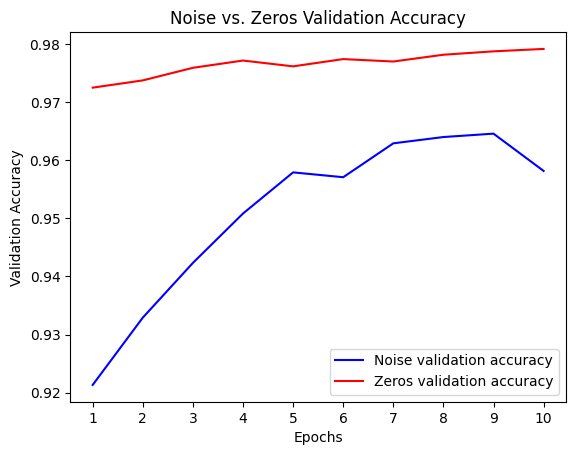

In [16]:
import matplotlib.pyplot as plt

noise_history_dict = modelWithNoise.history
zeros_history_dict = modelWithZeros.history
noise_acc_values = noise_history_dict["val_accuracy"]
zeros_acc_values = zeros_history_dict["val_accuracy"]
epochs = range(1, len(noise_acc_values) + 1)
plt.plot(epochs, noise_acc_values, "b", label="Noise validation accuracy")
plt.plot(epochs, zeros_acc_values, "r", label="Zeros validation accuracy")
plt.title("Noise vs. Zeros Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

Rechargez et prétraitez MNIST (flatten + normalisation).  
Créez ensuite une copie des labels d’entraînement et **mélangez-la aléatoirement** (shuffle) pour casser la relation image→label.

Construisez un modèle dense (512 ReLU → 10 Softmax), compilez-le avec :
- optimizer = `"rmsprop"`
- loss = `"sparse_categorical_crossentropy"`
- metric = `"accuracy"`

Puis entraînez-le sur les **labels mélangés** pendant 100 époques (batch_size=128, validation_split=0.2).

En repartant de MNIST prétraité, entraînez un modèle Dense(512 ReLU → 10 Softmax) en utilisant l’optimiseur **RMSprop** avec un **learning rate très élevé** (par ex. 1.0).  
Entraînez 10 époques (batch_size=128, validation_split=0.2) et observez la stabilité de l’apprentissage.

Ré-entraînez le même modèle MNIST (même architecture) mais avec RMSprop et un **learning rate plus faible** (par ex. 1e-2).  
Comparez qualitativement l’apprentissage avec le cas précédent (lr=1.0).

Construisez un modèle **très simple** pour MNIST : une seule couche `Dense(10, activation="softmax")`.  
Compilez-le (optimizer="rmsprop", loss="sparse_categorical_crossentropy", metric="accuracy") puis entraînez-le 20 époques (batch_size=128, validation_split=0.2).  
Conservez l’historique sous un nom explicite (ex : `history_small_model`).

À partir de `history_small_model`, récupérez la **validation loss** et tracez-la en fonction des 20 époques.  
Ajoutez titre, labels, légende et affichez la figure.

Construisez un modèle plus capacitaire pour MNIST :
- Dense(128, relu)
- Dense(128, relu)
- Dense(10, softmax)

Compilez (rmsprop + sparse_categorical_crossentropy + accuracy) puis entraînez 20 époques (batch_size=128, validation_split=0.2).  
Stockez l’historique (ex : `history_large_model`).

Tracez la **validation loss** de `history_large_model` sur 20 époques (graphique similaire au cas précédent) pour comparer l’évolution avec le petit modèle.

Construisez un modèle **très capacitaire** pour MNIST avec trois couches cachées :
- Dense(2048, relu) × 3
- Dense(10, softmax)

Compilez comme précédemment, puis entraînez 20 époques avec un batch_size plus petit (par ex. 32) et validation_split=0.2.  
Stockez l’historique (ex : `history_very_large_model`).

Tracez la **validation loss** du modèle très grand sur 20 époques afin d’illustrer le risque de surapprentissage lorsque la capacité est excessive.

Chargez le dataset **IMDB** (en limitant le vocabulaire aux 10 000 mots les plus fréquents).  
Implémentez une fonction `vectorize_sequences` qui transforme chaque séquence d’indices en vecteur **one-hot** de dimension 10 000.

Entraînez ensuite un modèle de base pour la classification binaire :
- Dense(16, relu)
- Dense(16, relu)
- Dense(1, sigmoid)

Compilez (optimizer="rmsprop", loss="binary_crossentropy", metric="accuracy")  
Entraînez 20 époques (batch_size=512, validation_split=0.4) et stockez l’historique (`history_original`).

En gardant le même prétraitement IMDB, entraînez un modèle plus petit :
- Dense(4, relu)
- Dense(4, relu)
- Dense(1, sigmoid)

Même compilation et mêmes hyperparamètres d’entraînement (20 époques, batch_size=512, validation_split=0.4).  
Stockez l’historique (`history_smaller_model`).

Tracez sur un même graphique la **validation loss** du modèle original (`history_original`) et du modèle plus petit (`history_smaller_model`) sur 20 époques, avec titre, axes, ticks et légende.

Toujours sur IMDB vectorisé, entraînez un modèle beaucoup plus grand :
- Dense(512, relu)
- Dense(512, relu)
- Dense(1, sigmoid)

Même compilation et mêmes paramètres d’entraînement (20 époques, batch_size=512, validation_split=0.4).  
Stockez l’historique (`history_larger_model`).

Tracez sur un même graphique la **validation loss** du modèle original (`history_original`) et du modèle plus grand (`history_larger_model`) pour illustrer l’effet d’une capacité excessive sur la généralisation.

En apprentissage profond, la régularisation regroupe des techniques destinées à améliorer la **généralisation** du modèle, c’est-à-dire sa capacité à bien fonctionner sur des données nouvelles, et non seulement sur les données d’entraînement.

---

## 1. Régularisation des poids (L1, L2)

La régularisation des poids consiste à ajouter une pénalité lors de l’entraînement lorsque les poids du réseau deviennent trop grands.  
L’objectif est d’éviter que le modèle ne devienne trop complexe ou trop sensible à des détails spécifiques du jeu d’entraînement.

### L2 (weight decay)

- Encourage les poids à rester petits.
- Rend le modèle plus stable et plus lisse.
- Réduit le risque de surapprentissage.
- N’annule généralement pas complètement les poids.

C’est la forme de régularisation la plus couramment utilisée.

---

### L1

- Encourage certains poids à devenir exactement nuls.
- Introduit une forme de sélection automatique de variables.
- Produit des modèles plus simples et plus parcimonieux.

Elle est utile lorsque l’on soupçonne que seules certaines caractéristiques sont réellement pertinentes.

---

### L1 + L2

- Combine les avantages des deux approches.
- Permet à la fois de limiter la taille des poids et d’en annuler certains.

---

## 2. Dropout

Le dropout est une technique différente :  
au lieu de pénaliser les poids, il modifie temporairement la structure du réseau pendant l’entraînement.

Concrètement :

- À chaque itération, une proportion aléatoire de neurones est désactivée.
- Le réseau ne peut donc pas s’appuyer toujours sur les mêmes neurones.
- Cela empêche les neurones de trop se spécialiser ou de se co-adapter.

Effets principaux :

- Apprentissage de représentations plus robustes.
- Réduction du surapprentissage.
- Effet comparable à une moyenne implicite de plusieurs sous-modèles.

Important :
- Le dropout est actif uniquement pendant l’entraînement.
- Il est automatiquement désactivé lors de la validation ou du test.

---

## 3. Différence essentielle

- La régularisation L1/L2 agit sur les **valeurs des poids**.
- Le dropout agit sur la **structure temporaire du réseau pendant l’entraînement**.

Les deux techniques peuvent être combinées et sont souvent utilisées ensemble pour améliorer la généralisation d’un modèle.

Modifiez le modèle IMDB (16-16-1) pour ajouter une régularisation **L2** sur les poids des couches denses (par ex. `l2(0.002)` via `kernel_regularizer`).  
Entraînez le modèle (mêmes hyperparamètres) et stockez l’historique (`history_l2_reg`).

In [ ]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Tracez sur un même graphique la **validation loss** du modèle original (`history_original`) et du modèle avec **L2** (`history_l2_reg`) sur 20 époques (titre + légende).

Importez `keras.regularizers` puis montrez comment créer :
- une régularisation L1 (ex : coefficient 0.001),
- une régularisation combinée L1+L2 (ex : 0.001 et 0.001).

In [ ]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

Construisez une variante du modèle IMDB (16-16-1) en ajoutant du **Dropout** après chaque couche Dense cachée (par ex. `Dropout(0.5)`).  
Compilez et entraînez avec les mêmes paramètres (20 époques, batch_size=512, validation_split=0.4).  
Stockez l’historique (`history_dropout`).

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

In [ ]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

# Task
Generate two sets of inputs for the MNIST dataset: one by concatenating 784 random noise variables to each image, and another by concatenating 784 zeros to each image.

## Create noise channels

### Subtask:
Générer 784 variables aléatoires (canaux de bruit) pour chaque image d'entraînement et de test.


**Reasoning**:
I need to import the `numpy` library, generate random noise channels for both training and test datasets with the specified dimensions, and then print their shapes to verify. `np.random.rand` will be used to generate random values between 0 and 1.



In [4]:
import numpy as np

# Generate 784 random noise channels for each training image
train_noise_channels = np.random.rand(train_images.shape[0], 784).astype('float32')

# Generate 784 random noise channels for each test image
test_noise_channels = np.random.rand(test_images.shape[0], 784).astype('float32')

print("Shape of train_noise_channels:", train_noise_channels.shape)
print("Shape of test_noise_channels:", test_noise_channels.shape)

Shape of train_noise_channels: (60000, 784)
Shape of test_noise_channels: (10000, 784)


## Concatenate noise to images

### Subtask:
Concaténer les canaux de bruit générés aux images MNIST prétraitées pour former le premier jeu d'entrées.


**Reasoning**:
I need to concatenate the generated noise channels with the MNIST images for both training and testing datasets. I will use `np.concatenate` for this purpose, specifying `axis=1` to combine them column-wise.



In [5]:
train_images_with_noise = np.concatenate((train_images, train_noise_channels), axis=1)
test_images_with_noise = np.concatenate((test_images, test_noise_channels), axis=1)

print("Shape of train_images_with_noise:", train_images_with_noise.shape)
print("Shape of test_images_with_noise:", test_images_with_noise.shape)

Shape of train_images_with_noise: (60000, 1568)
Shape of test_images_with_noise: (10000, 1568)


## Create zero channels

### Subtask:
Générer 784 zéros pour chaque image d'entraînement et de test.


**Reasoning**:
I need to create two NumPy arrays filled with zeros, `train_zero_channels` and `test_zero_channels`, with dimensions matching the number of samples in `train_images` and `test_images` respectively, and 784 columns, ensuring the data type is `float32`. Afterwards, I will print their shapes for verification.



In [6]:
import numpy as np

# Generate 784 zero channels for each training image
train_zero_channels = np.zeros((train_images.shape[0], 784), dtype='float32')

# Generate 784 zero channels for each test image
test_zero_channels = np.zeros((test_images.shape[0], 784), dtype='float32')

print("Shape of train_zero_channels:", train_zero_channels.shape)
print("Shape of test_zero_channels:", test_zero_channels.shape)

Shape of train_zero_channels: (60000, 784)
Shape of test_zero_channels: (10000, 784)


**Reasoning**:
Now that the zero channels are generated, I need to concatenate them with the MNIST images for both training and testing datasets to form the second input set as per the main task's instructions. I will use `np.concatenate` for this purpose, specifying `axis=1` to combine them column-wise, and then print the shapes to verify.



In [7]:
train_images_with_zeros = np.concatenate((train_images, train_zero_channels), axis=1)
test_images_with_zeros = np.concatenate((test_images, test_zero_channels), axis=1)

print("Shape of train_images_with_zeros:", train_images_with_zeros.shape)
print("Shape of test_images_with_zeros:", test_images_with_zeros.shape)

Shape of train_images_with_zeros: (60000, 1568)
Shape of test_images_with_zeros: (10000, 1568)


## Summary:

### Q&A
Two sets of inputs were generated for the MNIST dataset: one by concatenating 784 random noise variables to each image, and another by concatenating 784 zeros to each image.

### Data Analysis Key Findings
*   784 random noise variables were generated for each of the 60,000 training images and 10,000 test images, resulting in `train_noise_channels` with shape (60000, 784) and `test_noise_channels` with shape (10000, 784). The values are random floats between 0 and 1.
*   These noise channels were successfully concatenated with the original images, creating `train_images_with_noise` of shape (60000, 1568) and `test_images_with_noise` of shape (10000, 1568). Each image now has 784 original features + 784 noise features, totaling 1568 features.
*   784 zero variables were generated for each of the 60,000 training images and 10,000 test images, forming `train_zero_channels` of shape (60000, 784) and `test_zero_channels` of shape (10000, 784). The values are all zeros with `float32` data type.
*   These zero channels were successfully concatenated with the original images, resulting in `train_images_with_zeros` of shape (60000, 1568) and `test_images_with_zeros` of shape (10000, 1568). Each image now has 784 original features + 784 zero features, totaling 1568 features.

### Insights or Next Steps
*   These two new datasets are ready for training machine learning models to analyze the impact of irrelevant features (random noise versus constant zeros) on model performance and robustness.
*   The generated datasets can be used to compare how well models distinguish true features from noise or constant irrelevant features, potentially revealing insights into model generalization capabilities.
